In [44]:
from sktime.datasets import load_tsf_to_dataframe
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
import numpy as np
from catboost import CatBoostRegressor
from typing import Callable
import random

df, metadata = load_tsf_to_dataframe("./m4_yearly_dataset.tsf")

In [4]:
pd.set_option('display.max_rows', None)
print(df.head(36))
pd.reset_option('display.max_rows')

                                           series_value
series_name start_timestamp     timestamp              
T1          1979-01-01 12:00:00 0                5172.1
                                1                5133.5
                                2                5186.9
                                3                5084.6
                                4                5182.0
                                5                5414.3
                                6                5576.2
                                7                5752.9
                                8                5955.2
                                9                6087.8
                                10               6238.9
                                11               6317.2
                                12               6262.7
                                13               6361.0
                                14               6427.4
                                15              

In [5]:
df_reset = df.reset_index()
print(df_reset['series_name'].unique())

['T1' 'T2' 'T3' ... 'T22998' 'T22999' 'T23000']


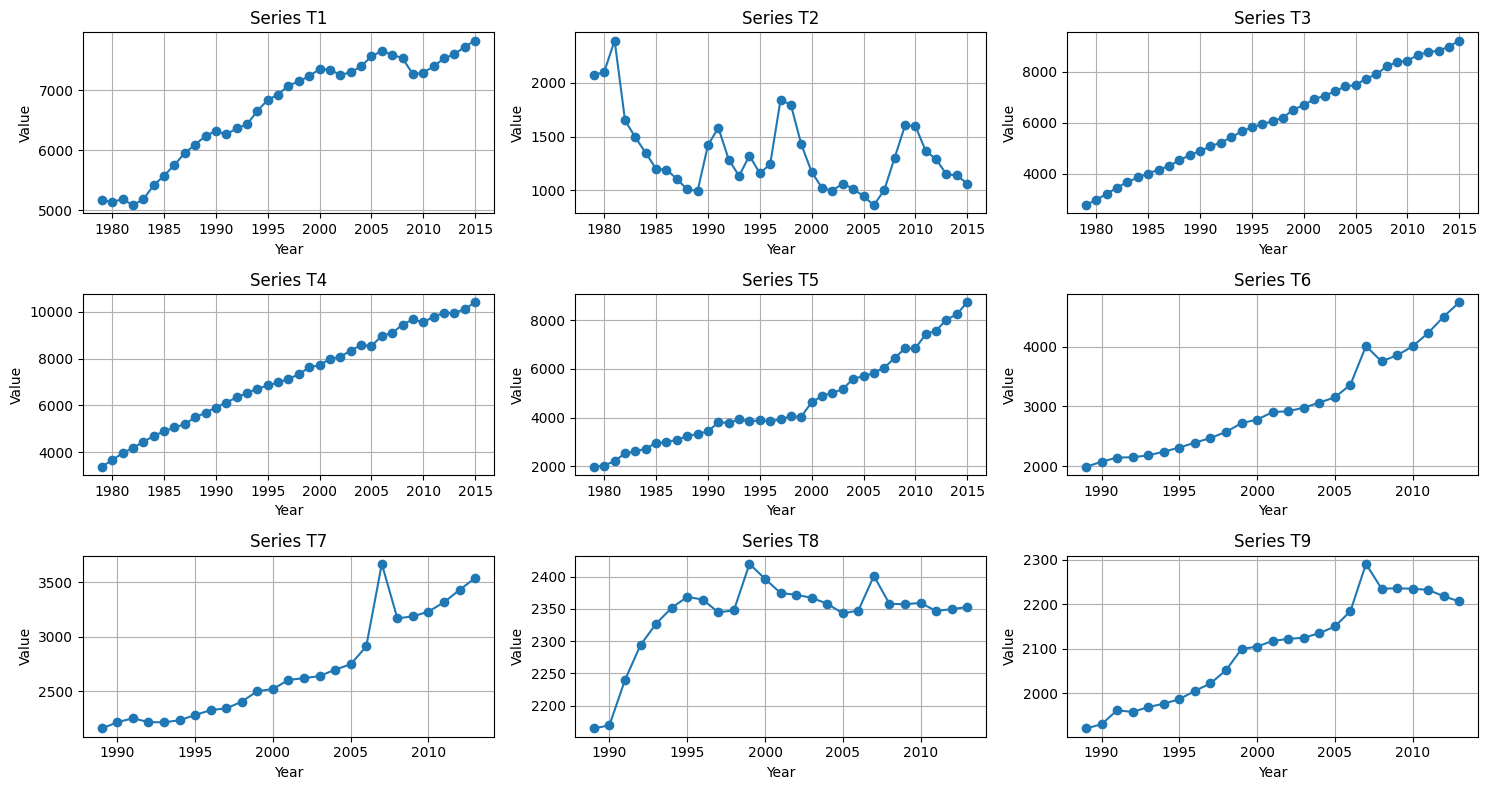

In [29]:
series_names = df_reset['series_name'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, name in enumerate(series_names):
    series_data = df_reset[df_reset['series_name'] == name].copy()
    start_year = pd.to_datetime(series_data['start_timestamp'].iloc[0]).year
    series_data['year'] = start_year + series_data['timestamp']
    
    axes[i].plot(series_data['year'], series_data['series_value'], marker='o', linestyle='-')
    axes[i].set_title(f'Series {name}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [6]:
grouped = df_reset.groupby('series_name')['series_value'].apply(list).reset_index()
grouped.columns = ['series_name', 'values']  

grouped = grouped[grouped['values'].apply(len) >= 40]

grouped = grouped.sort_values('series_name')

selected = grouped.head(150)

series_list = selected['values'].tolist()
series_names = selected['series_name'].tolist()

print(f"Отобрано {len(series_list)} рядов с длиной >= 40")
print("Минимальная длина среди отобранных:", min(len(v) for v in series_list))
print("Средняя длина среди отобранных:", np.mean([len(v) for v in series_list]))

Отобрано 150 рядов с длиной >= 40
Минимальная длина среди отобранных: 40
Средняя длина среди отобранных: 51.04666666666667


In [8]:
X = to_time_series_dataset(series_list)
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

Обучаем модель с k=1...
Обучаем модель с k=2...
Обучаем модель с k=3...
Обучаем модель с k=4...
Обучаем модель с k=5...
Обучаем модель с k=6...
Обучаем модель с k=7...
Обучаем модель с k=8...
Обучаем модель с k=9...
Обучаем модель с k=10...


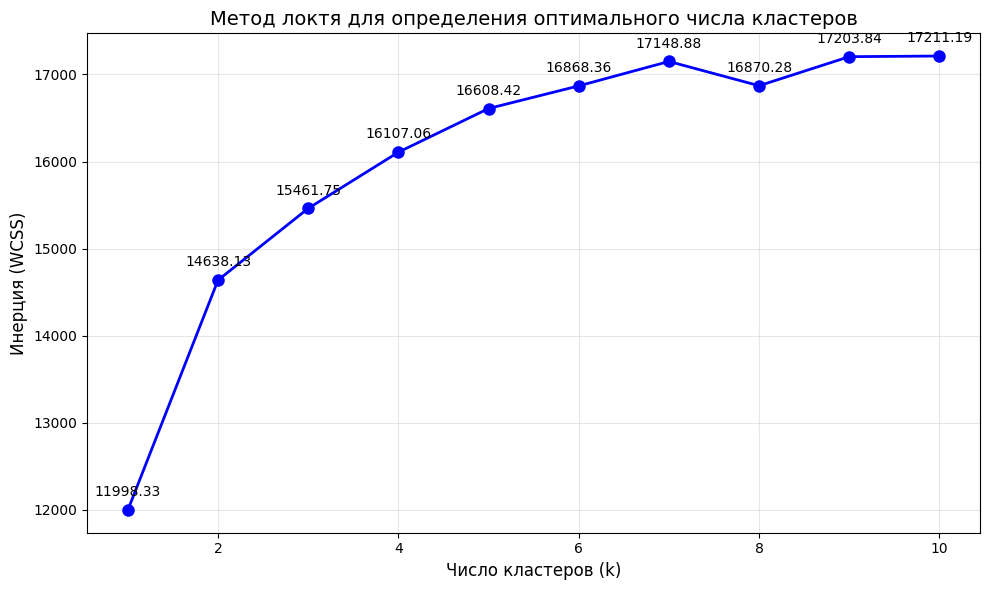


Таблица инерции по числу кластеров:
k	Инерция
1	11998.33
2	14638.13
3	15461.75
4	16107.06
5	16608.42
6	16868.36
7	17148.88
8	16870.28
9	17203.84
10	17211.19


In [ ]:
k_range = range(1, 11)
inertias = []

for k in k_range:
    print(f"Обучаем модель с k={k}...")

    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="softdtw",
        max_iter=50,
        max_iter_barycenter=10,
        random_state=0,
        verbose=0
    ).fit(X_scaled)

    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Инерция (WCSS)', fontsize=12)
plt.title('Метод локтя для определения оптимального числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)

for i, inertia in enumerate(inertias):
    plt.annotate(f'{inertia:.2f}', (k_range[i], inertia),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print("\nТаблица инерции по числу кластеров:")
print("k\tИнерция")
for k, inertia in zip(k_range, inertias):
    print(f"{k}\t{inertia:.2f}")


In [9]:
km_dba = TimeSeriesKMeans(
    n_clusters=7,
    metric="softdtw",
    max_iter=5,
    max_iter_barycenter=5,
    random_state=0
).fit(X_scaled)

cluster_labels = km_dba.labels_
print("Метки кластеров:", cluster_labels)

Метки кластеров: [4 3 3 5 1 5 6 2 0 1 6 0 4 0 5 3 3 3 3 1 3 3 4 4 3 3 6 6 5 1 4 6 4 2 5 3 2
 4 3 6 3 2 3 5 0 1 3 5 4 1 1 2 5 5 4 5 4 4 3 3 6 5 1 5 3 6 4 5 5 1 1 3 5 4
 3 4 5 5 1 1 3 4 5 4 5 2 5 3 1 2 6 1 6 5 3 3 4 6 1 1 6 4 0 3 4 1 2 0 2 0 0
 3 3 3 0 2 1 1 1 1 1 6 2 2 2 1 3 3 1 2 3 6 3 6 2 1 3 3 3 2 2 1 1 2 1 1 6 5
 3 2]


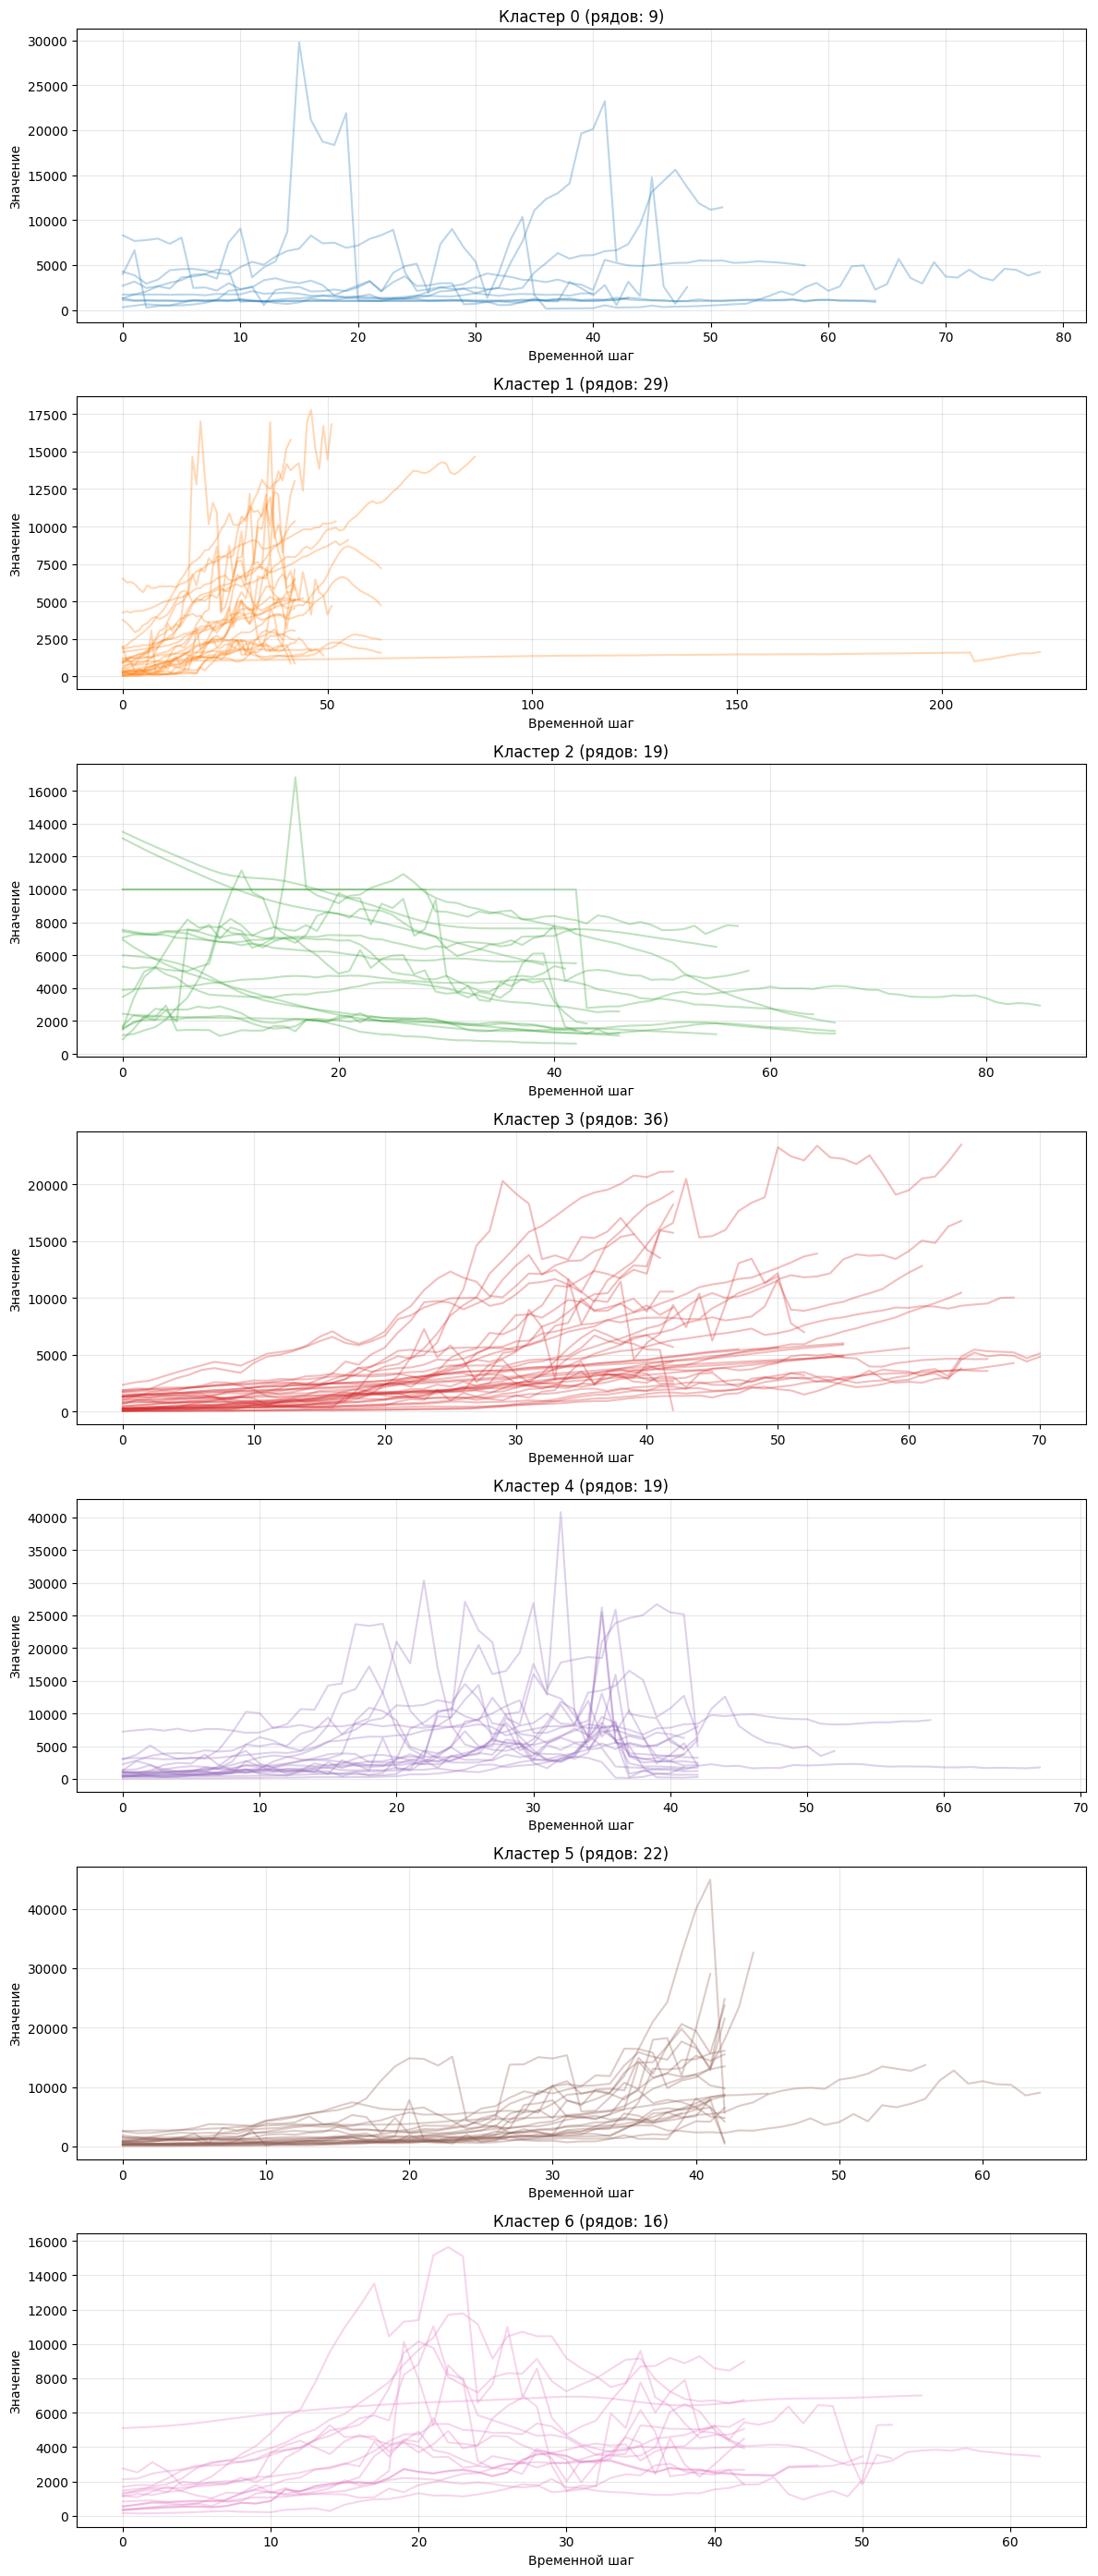

In [10]:
centroids = km_dba.cluster_centers_
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters))
if n_clusters == 1:
    axes = [axes]

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]    
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    for idx in cluster_indices:
        series_values = series_list[idx]   # значения ряда
        ax.plot(series_values, alpha=0.3, color=f'C{cluster_id}')
    
    ax.set_title(f'Кластер {cluster_id} (рядов: {len(cluster_indices)})')
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

naive_smape_list = []
for values in series_list:
    train = values[:-6]
    test = values[-6:]
    naive_forecast = np.full(6, train[-1])  
    naive_smape_list.append(smape(test, naive_forecast))

unique_clusters = np.unique(cluster_labels)
for cl in unique_clusters:
    indices = np.where(cluster_labels == cl)[0]
    smapes_cluster = [naive_smape_list[i] for i in indices]
    mean_smape = np.mean(smapes_cluster)
    lengths_cluster = [len(series_list[i]) for i in indices]  
    mean_length = np.mean(lengths_cluster) 
    
    print(f"Кластер {cl}: {len(indices)} рядов, средний Naïve sMAPE = {mean_smape:.2f}, средняя длина ряда = {mean_length:.1f}")


Кластер 0: 9 рядов, средний Naïve sMAPE = 23.95, средняя длина ряда = 55.2
Кластер 1: 29 рядов, средний Naïve sMAPE = 15.41, средняя длина ряда = 55.5
Кластер 2: 19 рядов, средний Naïve sMAPE = 13.78, средняя длина ряда = 53.7
Кластер 3: 36 рядов, средний Naïve sMAPE = 13.57, средняя длина ряда = 53.7
Кластер 4: 19 рядов, средний Naïve sMAPE = 75.29, средняя длина ряда = 45.5
Кластер 5: 22 рядов, средний Naïve sMAPE = 38.76, средняя длина ряда = 44.6
Кластер 6: 16 рядов, средний Naïve sMAPE = 26.32, средняя длина ряда = 46.9


In [131]:
def get_train(
        series_list: list[list],
        cluster_labels: list[int],
        H: int = 6,
        L: int = 35,
    ):
    
    X_train, y_train = [], []
    rows_used_for_train = set()

    for idx, values in enumerate(series_list):
        cluster = cluster_labels[idx]
        N = len(values)
        
        if N >= L + H:
            rows_used_for_train.add(idx)
            
            for t in range(L, N - H + 1):
                feats = values[t - L:t].copy()
                X_train.append(np.append(feats, cluster))
                y_train.append(values[t:t + H])  # multi-output target
            
        else:
             print(f"WARNING: Series with index '{idx}' not used in train")

    feature_names = [f'lag_{i}' for i in range(L)] + ['cluster']
    X_train = pd.DataFrame(X_train, columns=feature_names)
    X_train['cluster'] = X_train['cluster'].astype(int)

    return X_train, np.array(y_train), rows_used_for_train


def fit(X_train, y_train):
    models: dict = {}
    clusters = set(X_train["cluster"])

    for cluster in sorted(clusters):
        cluster_mask = X_train["cluster"] == cluster
        
        x_train = X_train.loc[cluster_mask, X_train.columns != "cluster"]
        y_train_cluster = y_train[cluster_mask]  # shape = (n_samples_cluster, H)

        model = CatBoostRegressor(
            loss_function='MultiRMSE',  # Multi-output RMSE
            iterations=1500,
            learning_rate=0.1,
            depth=6,
            verbose=50,
            random_seed=42
        )

        model.fit(x_train, y_train_cluster)
        models[cluster] = model

    return models


def predict(
    models_map: dict,
    series_list: list[list],
    cluster_labels: list[int],
    feature_names: list,
    H: int = 6,
    L: int = 35,
    is_cluster_in_train: bool = False,
):
    catboost_smape_list = []
    predictions_list = []
    true_list = []
    row_index_list = []
    cluster_for_plot = []
    rows_tested = 0

    for idx, values in enumerate(series_list):
        cluster = cluster_labels[idx]
        N = len(values)
        if N >= L + H:
            rows_tested += 1
            
            test_feats = values[N - H - L:N - H].copy()

            if is_cluster_in_train:
                result_test_feats = np.append(test_feats, cluster).reshape(1, -1)
            else:
                result_test_feats = np.array(test_feats).reshape(1, -1)

            df_test = pd.DataFrame(result_test_feats, columns=feature_names)
            
            if is_cluster_in_train:
                df_test['cluster'] = df_test['cluster'].astype(int)
            
            model = models_map[cluster]
            pred = model.predict(df_test).flatten()
            
            true = values[N - H:]
            smape_val = 100 * np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred)))
            catboost_smape_list.append(smape_val)

            predictions_list.append(pred)
            true_list.append(true)
            row_index_list.append(idx)
            cluster_for_plot.append(cluster)
        else:
            catboost_smape_list.append(np.nan)

    return (
        catboost_smape_list,
        predictions_list,
        true_list,
        row_index_list,
        cluster_for_plot,
        rows_tested,
    )

In [143]:
def plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        L = 35,
        max_plots = 5,
        ):
    if len(predictions_list) > 0:
        n_plots = min(max_plots, len(predictions_list))
        sample_indices = random.sample(range(len(predictions_list)), n_plots)

        plt.figure(figsize=(15, 3 * n_plots))
        for i, idx_in_list in enumerate(sample_indices):
            plot_idx = row_index_list[idx_in_list]
            cluster_id = cluster_for_plot[idx_in_list]
            true_vals = true_list[idx_in_list]
            pred_vals = predictions_list[idx_in_list]

            values = series_list[plot_idx]
            N = len(values)

            hist_indices = list(range(N - 6 - L, N - 6))
            history = values[N - 6 - L:N - 6]
            test_indices = list(range(N - 6, N))

            plt.subplot(n_plots, 1, i + 1)
            plt.plot(hist_indices, history, 'b-o', label='История', markersize=4)
            plt.plot(test_indices, true_vals, 'g-o', label='Факт', markersize=4)
            plt.plot(test_indices, pred_vals, 'r--o', label='Прогноз CatBoost', markersize=4)
            naive = [history[-1]] * 6
            plt.plot(test_indices, naive, 'k:', label='Naïve', markersize=4)

            plt.title(f'Ряд {plot_idx}, кластер {cluster_id}')
            plt.xlabel('Индекс ряда')
            plt.ylabel('Значение')
            plt.legend()
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для визуализации прогнозов")

In [144]:
def print_smape(catboost_smape_list, cluster_labels):
    unique_clusters = np.unique(cluster_labels)
    print("CatBoost sMAPE по кластерам:")
    for cl in unique_clusters:
        indices = np.where(cluster_labels == cl)[0]
        valid_smapes = [catboost_smape_list[i] for i in indices if not np.isnan(catboost_smape_list[i])]
        if len(valid_smapes) > 0:
            mean_smape = np.mean(valid_smapes)
            print(f"Кластер {cl}: {len(valid_smapes)} рядов из {len(indices)}, средний CatBoost sMAPE = {mean_smape:.2f}")
        else:
            print(f"Кластер {cl}: нет данных для расчёта")

In [145]:
H = 6
L = 35
feature_names = [f'lag_{i}' for i in range(L)]

In [146]:
X_train, y_train, _ = get_train(series_list, cluster_labels, H, L)
trained_models = fit(X_train, y_train)
(
	catboost_smape_list,
    predictions_list,
    true_list,
    row_index_list,
    cluster_for_plot,
    rows_tested,
) = predict(trained_models, series_list, cluster_labels, feature_names)

0:	learn: 8286.9035277	total: 11.9ms	remaining: 17.9s
50:	learn: 2107.7210174	total: 120ms	remaining: 3.42s
100:	learn: 1206.4158029	total: 227ms	remaining: 3.15s
150:	learn: 742.5070058	total: 316ms	remaining: 2.83s
200:	learn: 467.0314988	total: 406ms	remaining: 2.62s
250:	learn: 317.6453560	total: 498ms	remaining: 2.48s
300:	learn: 219.4750598	total: 588ms	remaining: 2.34s
350:	learn: 158.3339883	total: 678ms	remaining: 2.22s
400:	learn: 115.0380470	total: 773ms	remaining: 2.12s
450:	learn: 82.4680943	total: 877ms	remaining: 2.04s
500:	learn: 60.9046829	total: 970ms	remaining: 1.93s
550:	learn: 43.7925081	total: 1.06s	remaining: 1.83s
600:	learn: 31.4406120	total: 1.16s	remaining: 1.74s
650:	learn: 23.2386298	total: 1.26s	remaining: 1.64s
700:	learn: 17.1824646	total: 1.35s	remaining: 1.54s
750:	learn: 12.4527969	total: 1.45s	remaining: 1.44s
800:	learn: 9.2359981	total: 1.54s	remaining: 1.35s
850:	learn: 6.8252039	total: 1.64s	remaining: 1.25s
900:	learn: 5.0754675	total: 1.75s	rem

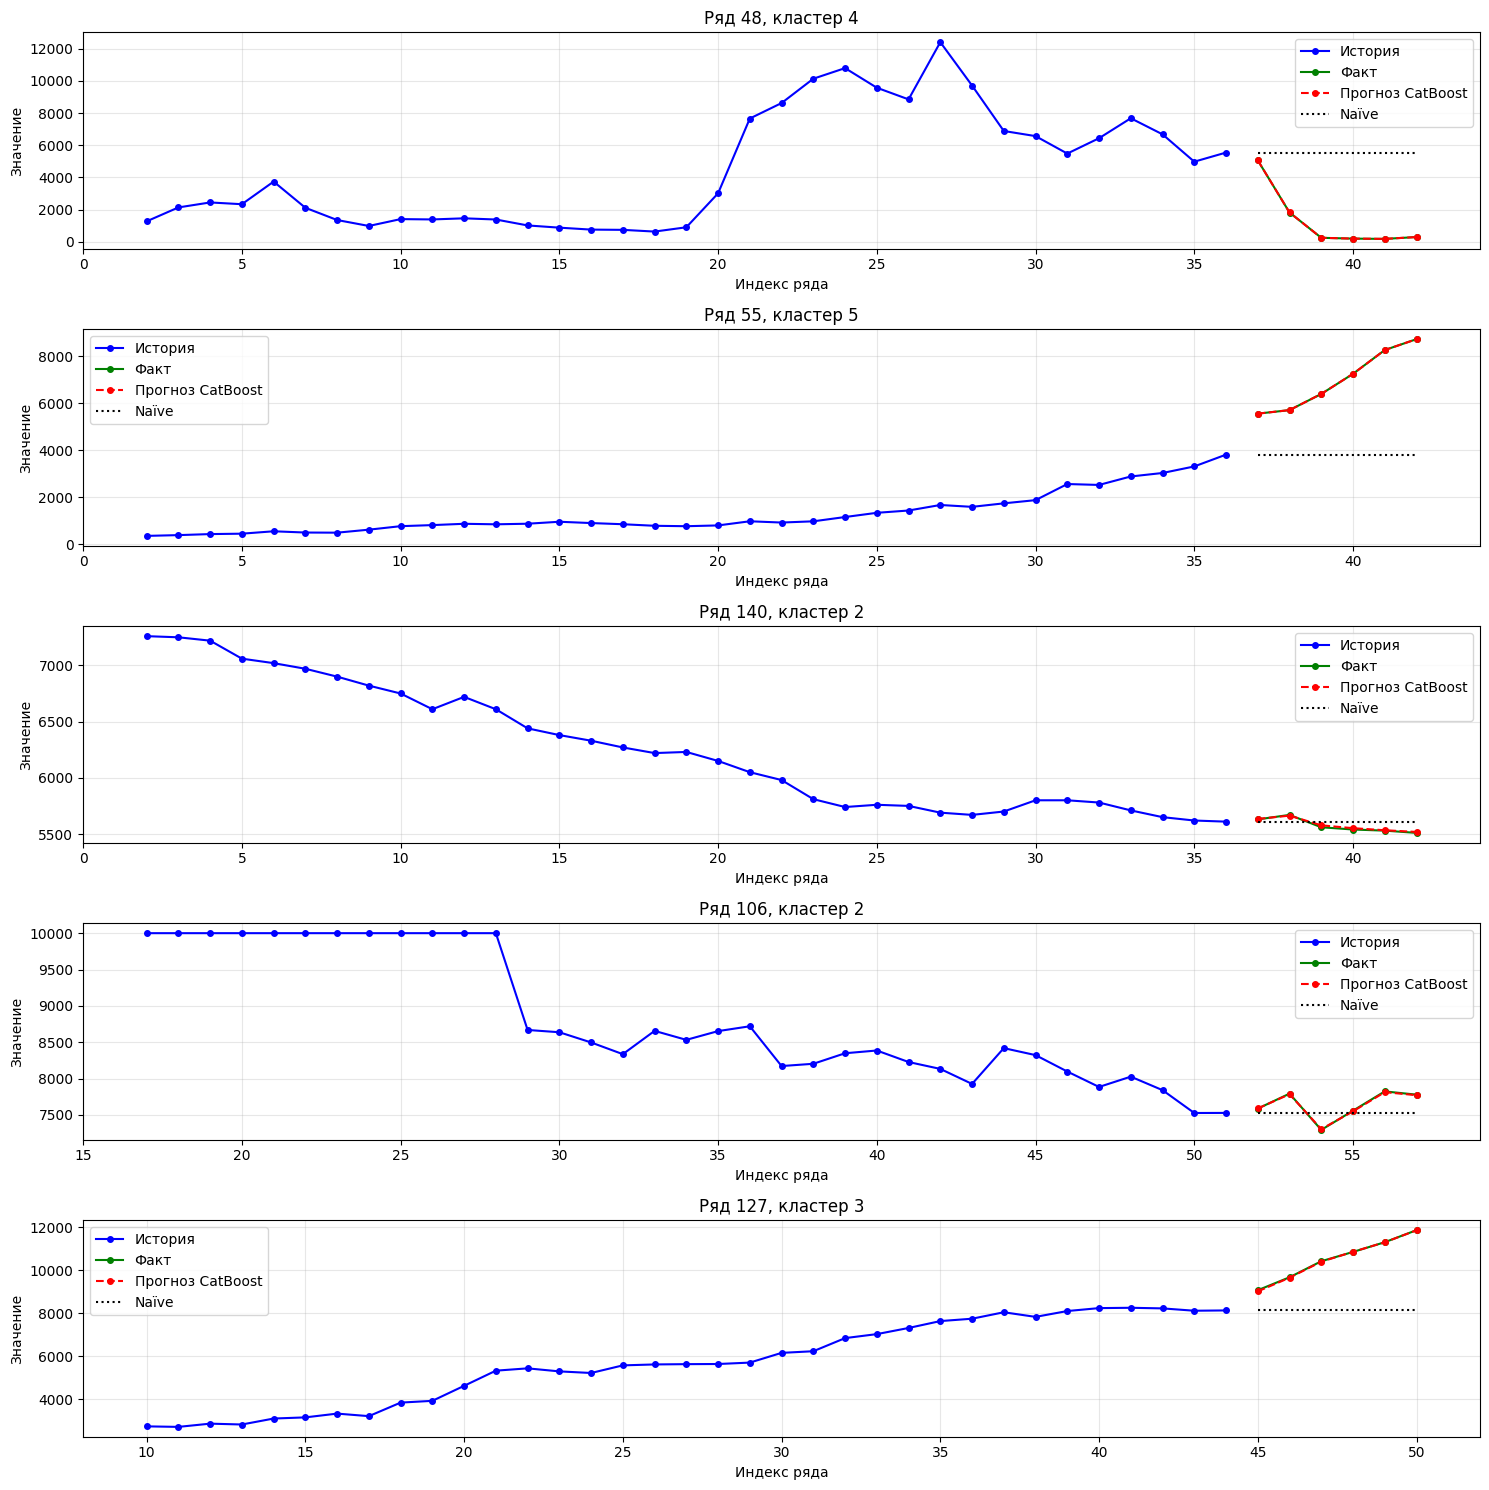

In [147]:
plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        )

In [148]:
print_smape(catboost_smape_list, cluster_labels)

CatBoost sMAPE по кластерам:
Кластер 0: 9 рядов из 9, средний CatBoost sMAPE = 0.00
Кластер 1: 28 рядов из 29, средний CatBoost sMAPE = 0.16
Кластер 2: 18 рядов из 19, средний CatBoost sMAPE = 0.22
Кластер 3: 35 рядов из 36, средний CatBoost sMAPE = 0.46
Кластер 4: 19 рядов из 19, средний CatBoost sMAPE = 0.00
Кластер 5: 21 рядов из 22, средний CatBoost sMAPE = 0.01
Кластер 6: 16 рядов из 16, средний CatBoost sMAPE = 0.01


## BoxCox

In [149]:

def find_best_lambda(
    series: np.ndarray,
    lambda_min: float = 0,
    lambda_max: float = 2,
    n_lambdas: int = 50,
) -> float:
    
    series = np.asarray(series, dtype=np.float64)
    n = len(series)

    series = np.maximum(series, 1e-12)

    lambdas = np.linspace(lambda_min, lambda_max, n_lambdas)

    best_lambda = 0.0
    best_ll = -np.inf

    log_series = np.log(series)

    for lam in lambdas:
        try:
            if abs(lam) < 1e-3:
                transformed = log_series
            else:
                transformed = (np.power(series, lam) - 1) / lam

            if not np.all(np.isfinite(transformed)):
                continue

            variance = np.var(transformed)

            if not np.isfinite(variance) or variance <= 0:
                continue

            log_likelihood = -n / 2 * np.log(variance) + (lam - 1) * np.sum(log_series)

            if np.isfinite(log_likelihood) and log_likelihood > best_ll:
                best_ll = log_likelihood
                best_lambda = lam

        except Exception:
            continue

    return best_lambda


def boxcox_transform(series, lambda_param=None):
    
    series = np.asarray(series, dtype=np.float64)

    if np.any(series <= 0):
        shift = abs(series.min()) + 1
        series = series + shift
    else:
        shift = 0.0

    series = np.maximum(series, 1e-12)
    series = np.clip(series, 1e-12, 1e6)

    if lambda_param is None:
        lambda_param = find_best_lambda(series)

    if abs(lambda_param) < 1e-5:
        transformed = np.log(series)
    else:
        transformed = (np.power(series, lambda_param) - 1) / lambda_param

    transformed = np.clip(transformed, -50, 50)

    return transformed, lambda_param, shift


def inverse_boxcox(transformed_series, lambda_param, shift=0.0):
    
    transformed = np.asarray(transformed_series, dtype=np.float64)

    if abs(lambda_param) < 1e-3:
        original = np.exp(transformed)
    else:
        base = lambda_param * transformed + 1

        base = np.maximum(base, 1e-12)

        original = np.power(base, 1 / lambda_param)

    if shift != 0:
        original = original - shift

    return original


def boxcox_transform_series_list(series_list, lambdas=None):

    transformed_list = []
    used_lambdas = []
    shifts = []

    for i, series in enumerate(series_list):

        lam = None if lambdas is None else lambdas[i]

        transformed, lam, shift = boxcox_transform(series, lam)

        transformed_list.append(transformed)
        used_lambdas.append(lam)
        shifts.append(shift)

    return transformed_list, used_lambdas, shifts


def inverse_boxcox_series_list(transformed_list, lambdas, shifts):

    result = []

    for t, lam, shift in zip(transformed_list, lambdas, shifts):
        inv = inverse_boxcox(t, lam, shift)
        inv = np.clip(inv, -1e12, 1e12)

        result.append(inv)

    return result

In [150]:
boxcox_list, lambdas, shifts = boxcox_transform_series_list(series_list)

X_train, y_train, _ = get_train(boxcox_list, cluster_labels, H, L)

trained_models = fit(X_train, y_train)
feature_names = [f'lag_{i}' for i in range(L)]
(
	catboost_smape_list,
    predictions_list,
    true_list,
    row_index_list,
    cluster_for_plot,
    rows_tested,
) = predict(trained_models, series_list, cluster_labels, feature_names)

predictions_list = inverse_boxcox_series_list(predictions_list, lambdas, shifts)

0:	learn: 22.9364247	total: 6.63ms	remaining: 9.94s
50:	learn: 2.9462957	total: 99.1ms	remaining: 2.81s
100:	learn: 1.7129823	total: 175ms	remaining: 2.43s
150:	learn: 1.1688339	total: 261ms	remaining: 2.33s
200:	learn: 0.8370019	total: 421ms	remaining: 2.72s
250:	learn: 0.6025325	total: 531ms	remaining: 2.64s
300:	learn: 0.4514024	total: 627ms	remaining: 2.5s
350:	learn: 0.3472210	total: 716ms	remaining: 2.35s
400:	learn: 0.2691503	total: 816ms	remaining: 2.23s
450:	learn: 0.2172728	total: 908ms	remaining: 2.11s
500:	learn: 0.1721716	total: 998ms	remaining: 1.99s
550:	learn: 0.1398040	total: 1.15s	remaining: 1.98s
600:	learn: 0.1140547	total: 1.24s	remaining: 1.85s
650:	learn: 0.0919586	total: 1.34s	remaining: 1.75s
700:	learn: 0.0758932	total: 1.43s	remaining: 1.63s
750:	learn: 0.0625286	total: 1.53s	remaining: 1.52s
800:	learn: 0.0517414	total: 1.63s	remaining: 1.42s
850:	learn: 0.0424066	total: 1.72s	remaining: 1.31s
900:	learn: 0.0353331	total: 1.84s	remaining: 1.23s
950:	learn: 0

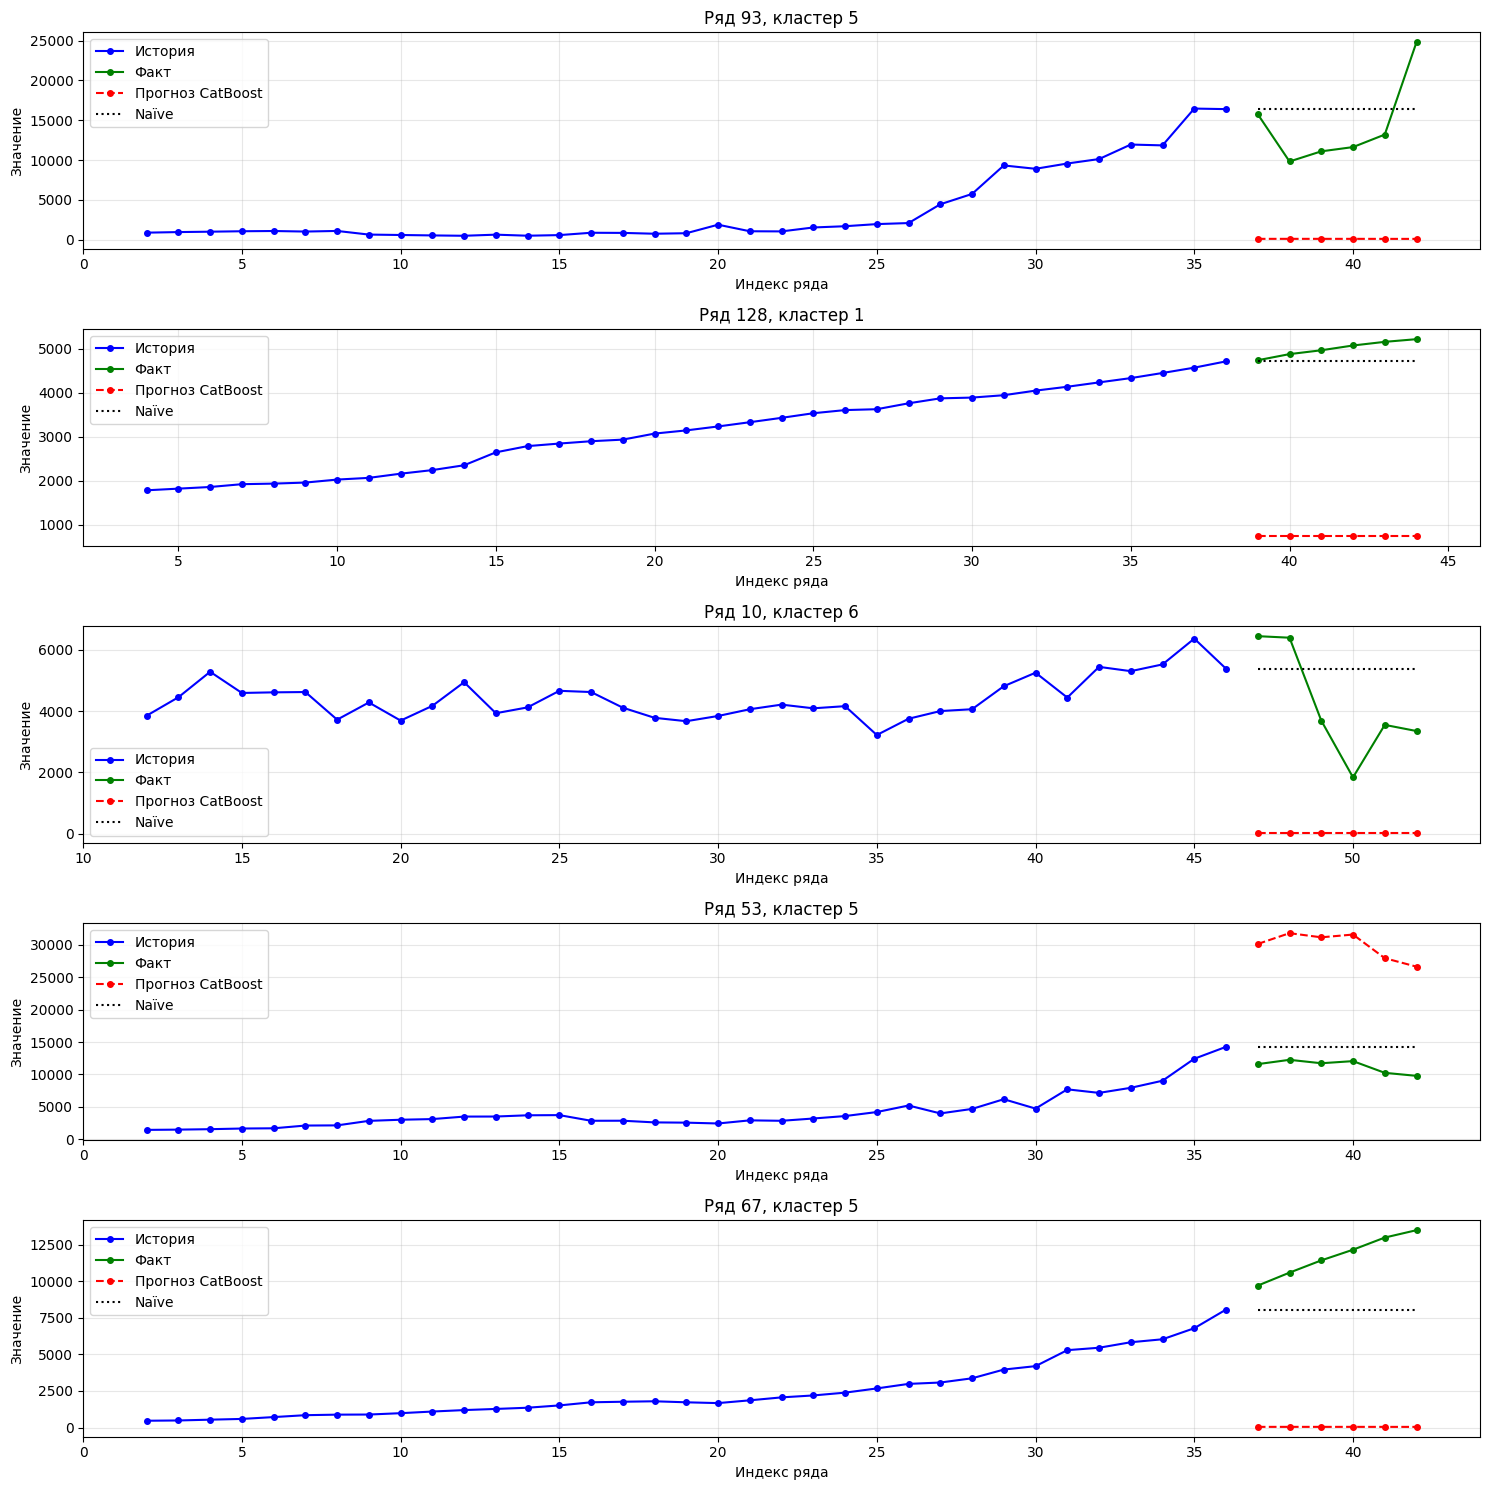

In [151]:
plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        )

## Log1P

In [152]:
def log1p_transform_series_list(series_list):
    transformed_list = []
    shifts = []
    for series in series_list:
        series = np.asarray(series, dtype=np.float64)
        min_val = series.min()
        shift = 0.0
        if min_val < 0:
            shift = abs(min_val) + 1e-8
            series = series + shift
        transformed = np.log1p(series)
        transformed_list.append(transformed)
        shifts.append(shift)
    return transformed_list, shifts

def inverse_log1p_series_list(transformed_list, shifts):
    original_list = []
    for t, shift in zip(transformed_list, shifts):
        series = np.expm1(t)
        if shift != 0:
            series = series - shift
        original_list.append(series)
    return original_list

In [ ]:
log1p_list, shifts = log1p_transform_series_list(series_list)
X_train, y_train, _ = get_train(log1p_list, cluster_labels, H, L)
trained_models = fit(X_train, y_train)
(
	catboost_smape_list,
    predictions_list,
    true_list,
    row_index_list,
    cluster_for_plot,
    rows_tested,
) = predict(trained_models, series_list, cluster_labels, feature_names)

predictions_list = inverse_log1p_series_list(predictions_list, shifts)

0:	learn: 2.3478403	total: 12.7ms	remaining: 19s
50:	learn: 0.5751080	total: 110ms	remaining: 3.12s
100:	learn: 0.3179927	total: 203ms	remaining: 2.81s
150:	learn: 0.2044027	total: 300ms	remaining: 2.68s
200:	learn: 0.1390289	total: 391ms	remaining: 2.52s
250:	learn: 0.1016127	total: 484ms	remaining: 2.41s
300:	learn: 0.0730654	total: 575ms	remaining: 2.29s
350:	learn: 0.0532959	total: 666ms	remaining: 2.18s
400:	learn: 0.0389210	total: 757ms	remaining: 2.07s
450:	learn: 0.0281061	total: 851ms	remaining: 1.98s
500:	learn: 0.0203497	total: 950ms	remaining: 1.89s
550:	learn: 0.0148703	total: 1.07s	remaining: 1.84s
600:	learn: 0.0109861	total: 1.17s	remaining: 1.75s
650:	learn: 0.0080888	total: 1.27s	remaining: 1.66s
700:	learn: 0.0057973	total: 1.37s	remaining: 1.56s
750:	learn: 0.0041856	total: 1.48s	remaining: 1.47s
800:	learn: 0.0030641	total: 1.57s	remaining: 1.37s
850:	learn: 0.0022528	total: 1.67s	remaining: 1.27s
900:	learn: 0.0016746	total: 1.77s	remaining: 1.18s
950:	learn: 0.00

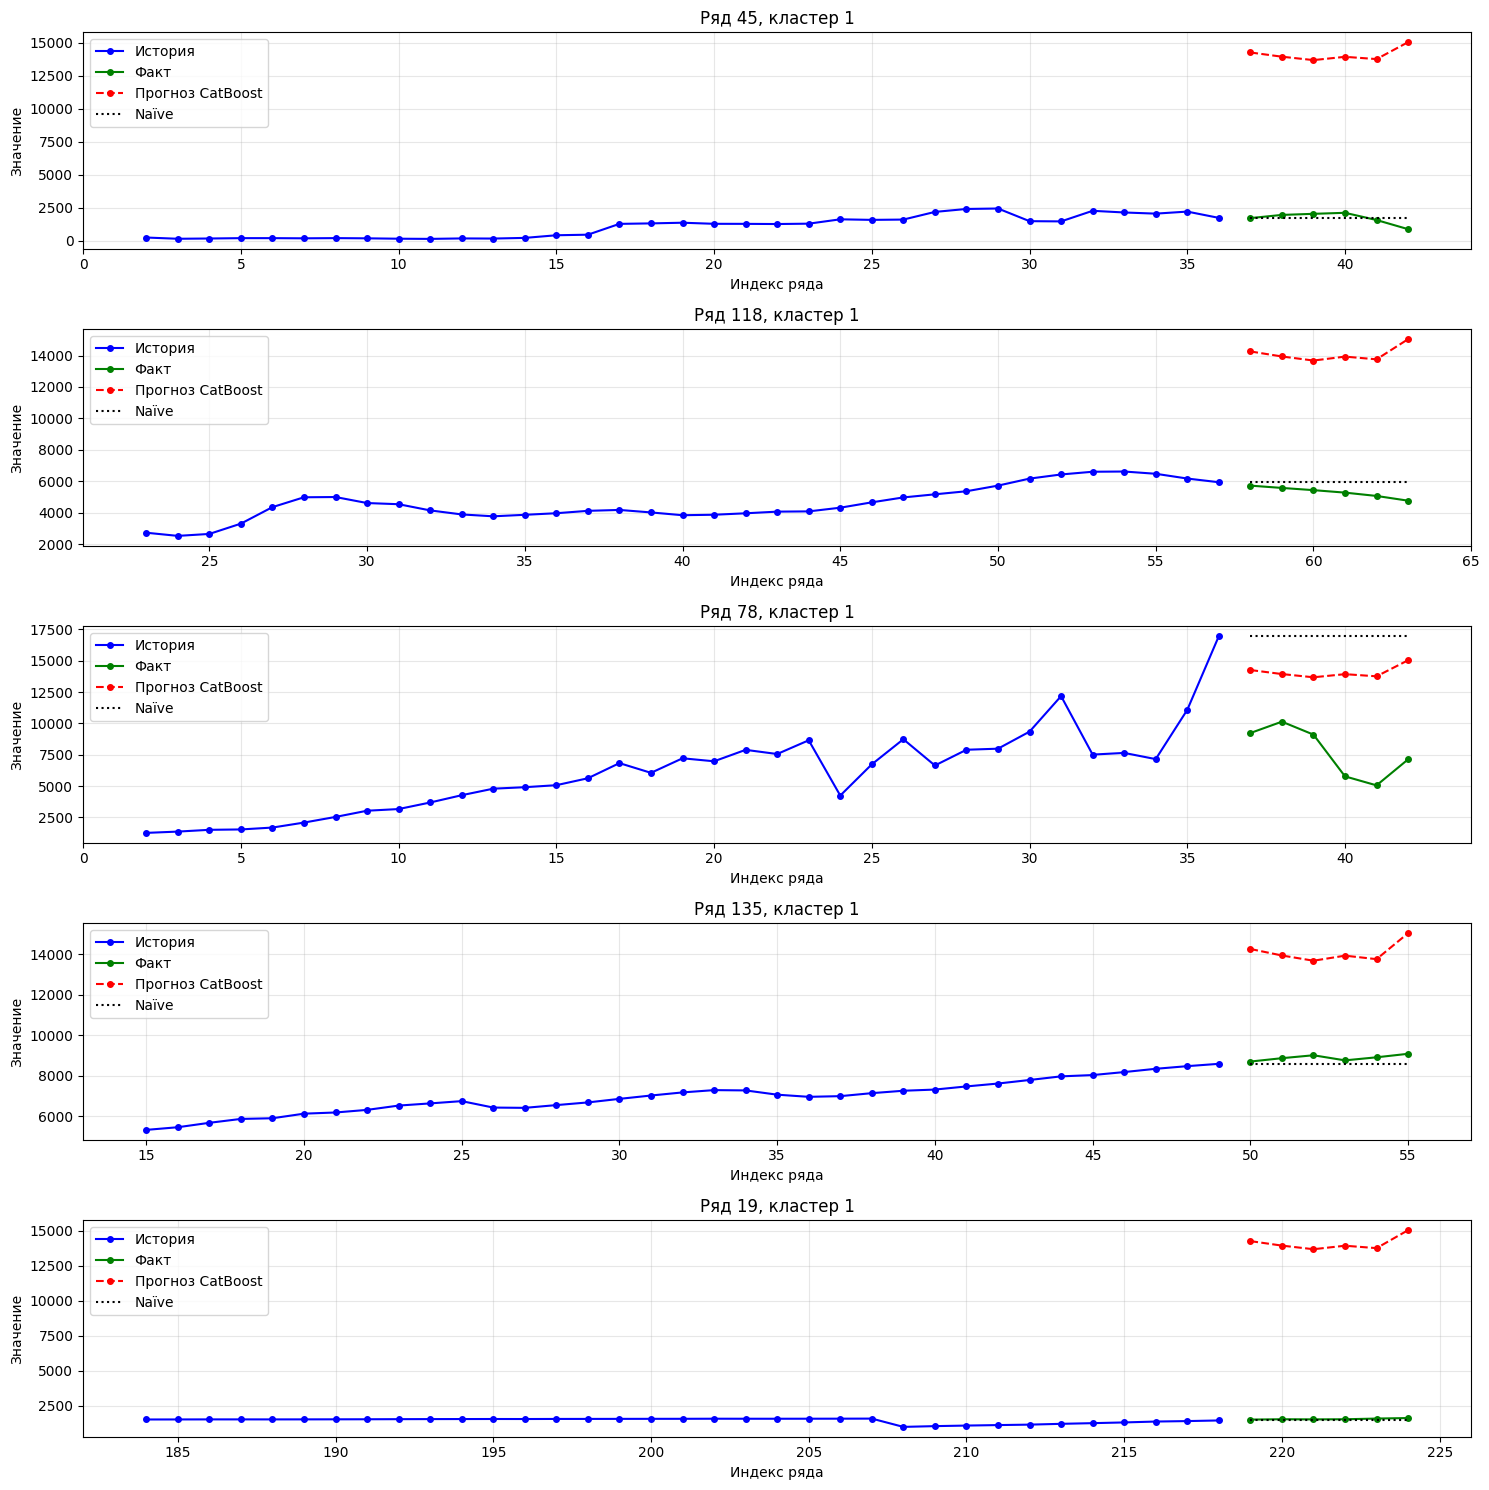

In [157]:
plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        )

## Дифференцирование

In [ ]:
def difference_series_list(series_list, order=1):
    diffed_list = []
    last_values_list = []
    for series in series_list:
        series = np.asarray(series, dtype=np.float64)
        last_values = series[:order].copy()
        diff = series.copy()
        for _ in range(order):
            diff = np.diff(diff, n=1)
        diffed_list.append(diff)
        last_values_list.append(last_values)
    return diffed_list, last_values_list

def inverse_difference(pred_diff, last_values, order=1):
    series = np.r_[last_values, pred_diff].cumsum()
    return series[-len(pred_diff):]

def inverse_difference_list(diffed_list, last_values_list):
    return [
    inverse_difference(pred, last_values_list[idx])
    for idx, pred in enumerate(predictions_list)
]

In [160]:
diffed_list, last_values_list = difference_series_list(series_list)
X_train, y_train, _ = get_train(diffed_list, cluster_labels, H, L)

trained_models = fit(X_train, y_train)
(
	catboost_smape_list,
    predictions_list,
    true_list,
    row_index_list,
    cluster_for_plot,
    rows_tested,
) = predict(trained_models, diffed_list, cluster_labels, feature_names)

predictions_list = inverse_difference(predictions_list, last_values_list)

0:	learn: 3992.4646860	total: 12.9ms	remaining: 19.4s
50:	learn: 1871.2587760	total: 105ms	remaining: 2.99s
100:	learn: 970.9828708	total: 191ms	remaining: 2.64s
150:	learn: 536.9544223	total: 295ms	remaining: 2.63s
200:	learn: 327.6812717	total: 383ms	remaining: 2.47s
250:	learn: 190.8463851	total: 470ms	remaining: 2.34s
300:	learn: 98.3092135	total: 560ms	remaining: 2.23s
350:	learn: 51.8483627	total: 648ms	remaining: 2.12s
400:	learn: 27.8719273	total: 739ms	remaining: 2.02s
450:	learn: 14.3658452	total: 834ms	remaining: 1.94s
500:	learn: 7.6204753	total: 930ms	remaining: 1.85s
550:	learn: 4.1073630	total: 1.03s	remaining: 1.77s
600:	learn: 2.2345814	total: 1.17s	remaining: 1.75s
650:	learn: 1.1706896	total: 1.28s	remaining: 1.67s
700:	learn: 0.6205015	total: 1.39s	remaining: 1.59s
750:	learn: 0.3445730	total: 1.51s	remaining: 1.51s
800:	learn: 0.1880920	total: 1.64s	remaining: 1.43s
850:	learn: 0.1015318	total: 1.74s	remaining: 1.33s
900:	learn: 0.0538638	total: 1.86s	remaining: 1.

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 6

In [ ]:
plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        )